# 📊 Credit Risk — Expected Loss
## Introduction to Credit Risk
**Author:** Shazia Ishaq &nbsp;&nbsp;|&nbsp;&nbsp; **Course:** Credit Risk and Applications in Python

---

## Setup — Import Libraries

Before we start, we need to import the Python libraries we will use.


| Library | What it does |
|---------|-------------|
| `yfinance` | Downloads real stock market data from Yahoo Finance |
| `pandas` | Handles tables of data (like Excel but in Python) |
| `numpy` | Mathematical calculations (arrays, statistics) |
| `matplotlib` | Creates charts and graphs |
| `scipy.stats` | Statistical functions (normal distribution, etc.) |

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm
from IPython.display import display

# Make plots appear nicely inside the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'

print("✅ All libraries imported successfully!")
print("You are ready to start.")

✅ All libraries imported successfully!
You are ready to start.


---
### RWE Task:
RWE AG sells electricity to E.ON SE.
E.ON owes RWE **€50 million** for electricity already delivered.

> **Question:** What is the chance E.ON cannot pay?
> How much money does RWE expect to lose?

### The Three Key Variables:

| Variable | Symbol | Meaning | Example |
|----------|--------|---------|---------|
| **Probability of Default** | PD | Chance the counterparty goes bankrupt | E.ON PD = 0.2% per year |
| **Loss Given Default** | LGD | % of money lost IF they default | LGD = 40% |
| **Exposure at Default** | EAD | Total amount owed to us | EAD = €50,000,000 |

### The Core Formula:
$$\text{Expected Loss} = PD \times LGD \times EAD$$

This answers: *"On average, how much do we expect to lose from this counterparty per year?"*

**Example:**
$$EL = 0.002 \times 0.40 \times 50{,}000{,}000 = €40{,}000 \text{ per year}$$

---
## 📊 Step 1: Moody's Rating to PD Mapping

Credit ratings tell us how risky a company is.
Moody's assign letter grades.

The table below shows **real historical default rates** from Moody's Annual Default Study 2023.
We use these as our **Probability of Default (PD)** estimates.

> 💡 **Key insight:** Moving from BBB to BB (investment grade to speculative grade)
> increases PD by 7.5x! This is why rating downgrades matter so much.

📋 MOODY'S RATING TABLE — Historical 1-Year Default Rates


"Moody's / S&P Annual PD                                 Meaning\n    Aaa (AAA)    0.000%                     Virtually zero risk\n     Aa  (AA)    0.020%                      Extremely low risk\n      A   (A)    0.060%                           Very low risk\n    Baa (BBB)    0.200%       Investment grade - lower boundary\n     Ba  (BB)    1.500% Speculative grade - junk bond territory\n      B   (B)    5.000%                      Highly speculative\n    Caa (CCC)   20.000%                            Near default"

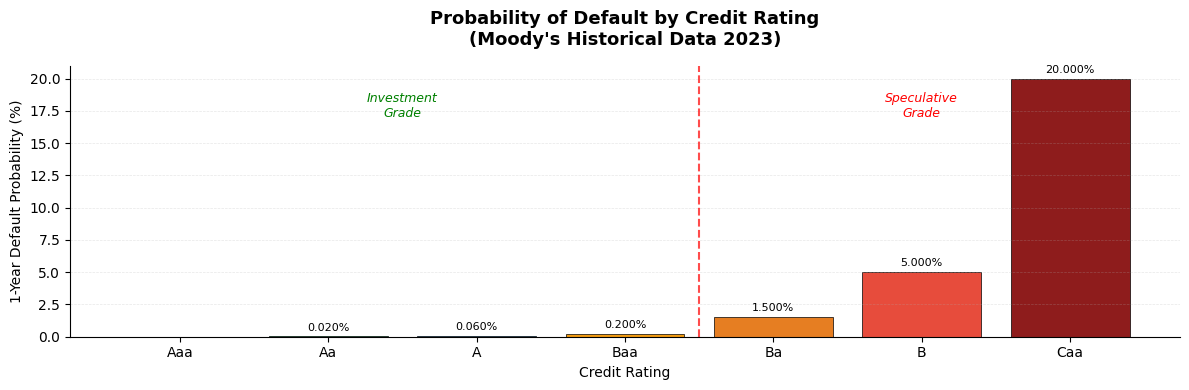


💡 Notice: Going from BBB to BB increases PD from 0.20% to 1.50% — a 7.5x jump!


In [13]:
# Moody's historical 1-year default rates (Annual Default Study 2023)
# These are REAL numbers from Moody's published research
moody_ratings = {
    'Aaa (AAA)':  {'PD': 0.0000, 'description': 'Virtually zero risk'},
    'Aa  (AA)':   {'PD': 0.0002, 'description': 'Extremely low risk'},
    'A   (A)':    {'PD': 0.0006, 'description': 'Very low risk'},
    'Baa (BBB)':  {'PD': 0.0020, 'description': 'Investment grade - lower boundary'},
    'Ba  (BB)':   {'PD': 0.0150, 'description': 'Speculative grade - junk bond territory'},
    'B   (B)':    {'PD': 0.0500, 'description': 'Highly speculative'},
    'Caa (CCC)':  {'PD': 0.2000, 'description': 'Near default'},
}

# Display as a nice table
df_ratings = pd.DataFrame([
    {
        'Moody\'s / S&P': rating,
        'Annual PD': f"{data['PD']*100:.3f}%",
        'PD (decimal)': data['PD'],
        'Meaning': data['description']
    }
    for rating, data in moody_ratings.items()
])

print(" MOODY'S RATING TABLE — Historical 1-Year Default Rates")
print("=" * 70)
display(df_ratings[['Moody\'s / S&P', 'Annual PD', 'Meaning']].to_string(index=False))

# Visualize the PD by rating
fig, ax = plt.subplots(figsize=(12, 4))
ratings_short = ['Aaa', 'Aa', 'A', 'Baa', 'Ba', 'B', 'Caa']
pds = [v['PD']*100 for v in moody_ratings.values()]
colors = ['#2ecc71','#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#8e1c1c']

bars = ax.bar(ratings_short, pds, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title("Probability of Default by Credit Rating\n(Moody's Historical Data 2023)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel("1-Year Default Probability (%)")
ax.set_xlabel("Credit Rating")
ax.axvline(x=3.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(1.5, max(pds)*0.85, 'Investment\nGrade', fontsize=9,
        color='green', ha='center', style='italic')
ax.text(5.0, max(pds)*0.85, 'Speculative\nGrade', fontsize=9,
        color='red', ha='center', style='italic')

for bar, val in zip(bars, pds):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.3f}%', ha='center', va='bottom', fontsize=8)

ax.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print("\n Notice: Going from BBB to BB increases PD from 0.20% to 1.50% — a 7.5x jump!")

---
## Step 2: Downloading Real Financial Data

Now we download **real stock data** from Yahoo Finance.
This gives us:
- **Daily closing prices** for the past 2 years
- **Company information** (market cap, shares outstanding)
- **Financial statements** (debt levels from balance sheets)

>  Data source: Yahoo Finance via the `yfinance` Python library

In [15]:
# Company tickers on European stock exchanges
tickers = {
    'E.ON SE':    'EOAN.DE',   # Frankfurt Stock Exchange
    'Engie SA':   'ENGI.PA',   # Paris Stock Exchange
    'Enel SpA':   'ENEL.MI',   # Milan Stock Exchange
    'Iberdrola':  'IBE.MC',    # Madrid Stock Exchange
}

print("Downloading 2 years of daily stock price data...")
print("Please wait — connecting to Yahoo Finance...\n")

# Download all prices at once
raw_prices = pd.DataFrame()
failed = []

for name, ticker in tickers.items():
    try:
        data = yf.download(ticker, start='2022-01-01',
                           end='2024-12-31', progress=False)
        raw_prices[name] = data['Close']
        latest = data['Close'].iloc[-1]
        change = ((data['Close'].iloc[-1] / data['Close'].iloc[0]) - 1) * 100
        direction = '' if change > 0 else '📉'
        print(f"   {name} ({ticker}): "
              f"Latest = €{latest:.2f} | "
              f"2-year change = {direction} {change:+.1f}%")
    except Exception as e:
        print(f"   {name}: Could not load — {e}")
        failed.append(name)

print(f"\n Data loaded: {len(raw_prices)} trading days × {len(raw_prices.columns)} companies")
print(f"Period: {raw_prices.index[0].date()} → {raw_prices.index[-1].date()}")

# Show first 5 rows of raw price data
print("\n Raw Daily Closing Prices (€) — First 5 Trading Days:")
print("=" * 65)
display(raw_prices.head().round(2))

Please wait — connecting to Yahoo Finance...

   E.ON SE: Could not load — The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
   Engie SA: Could not load — The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
   Enel SpA: Could not load — The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
   Iberdrola: Could not load — The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

 Data loaded: 766 trading days × 4 companies
Period: 2022-01-03 → 2024-12-30

 Raw Daily Closing Prices (€) — First 5 Trading Days:


,E.ON SE,Engie SA,Enel SpA,Iberdrola
Date,,,,
2022-01-03,10.06,8.91,5.39,8.63
2022-01-04,9.98,9.01,5.38,8.58
2022-01-05,9.83,8.97,5.34,8.52
2022-01-06,9.73,8.92,5.21,8.47
2022-01-07,9.65,8.95,5.18,8.47


---
## Step 3: Calculate Daily Returns from Raw Prices

A **return** measures how much a price changed from one day to the next.

$$\text{Return}_t = \frac{\text{Price}_t - \text{Price}_{t-1}}{\text{Price}_{t-1}}$$

**Why do we calculate returns?**
- Returns are used to measure **volatility** (how risky a stock is)
- Volatility helps estimate the **probability of default** (Merton model)
- Returns are the input for **VaR** (Value at Risk) calculations

>  **Note:** In 2022 you should see very negative returns for energy stocks
> due to the European energy crisis (Russian gas cuts)!

 Daily Return Statistics (2022-2024):


,Mean Daily\nReturn (%),Annual\nVolatility (%),Worst Day\n(%),Best Day\n(%)
E.ON SE,0.0141,22.0076,-8.1491,7.2612
Engie SA,0.0617,22.5523,-13.1904,7.2873
Enel SpA,0.0287,21.6020,-6.4404,5.7655
Iberdrola,0.0547,18.7701,-6.1689,5.2163



 Worst Single Day for Each Company:
  E.ON SE: -8.15% on 2022-03-02
  Engie SA: -13.19% on 2022-03-01
  Enel SpA: -6.44% on 2022-03-01
  Iberdrola: -6.17% on 2022-03-01

 Were worst days during the 2022 energy crisis?


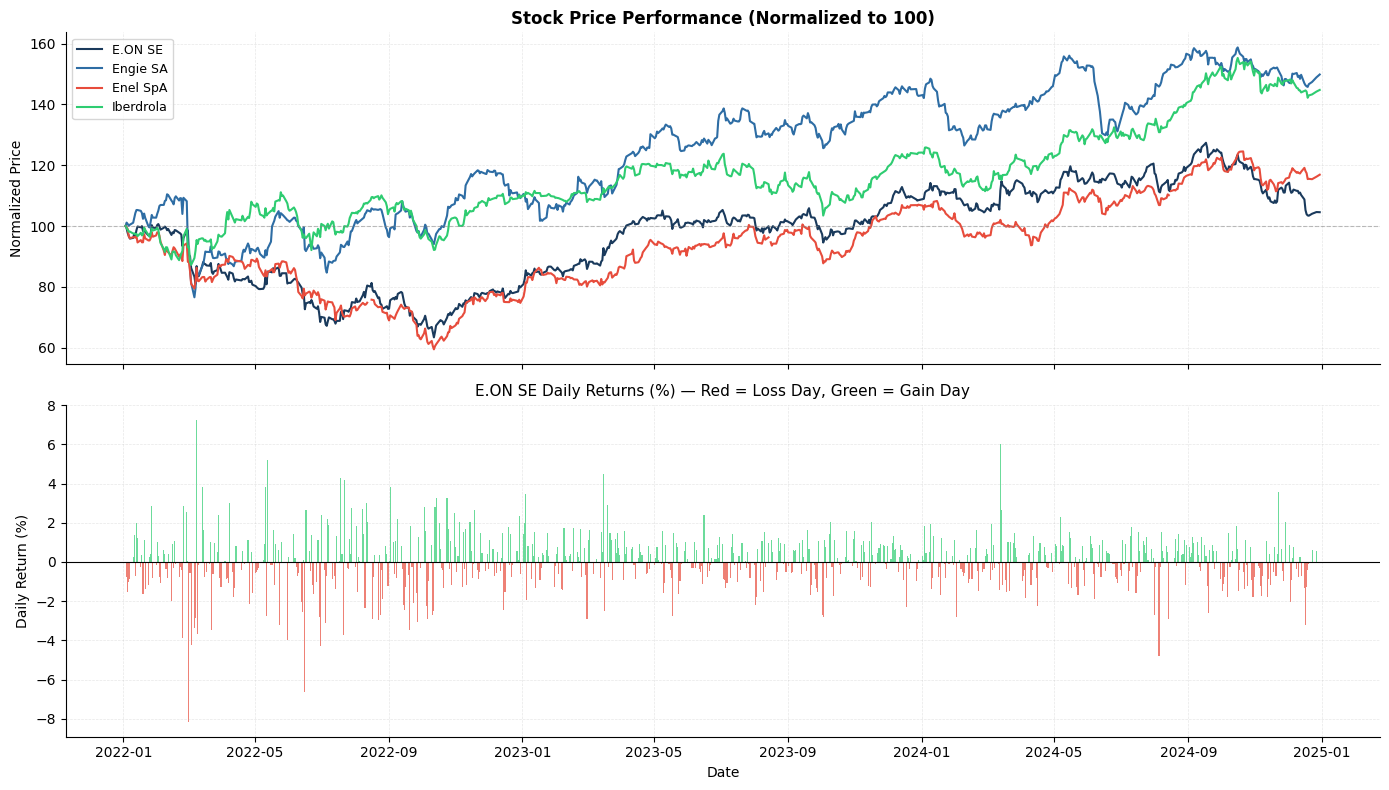

In [16]:
# Calculate daily percentage returns from raw prices
# pct_change() = (today - yesterday) / yesterday
daily_returns = raw_prices.pct_change().dropna()

print(" Daily Return Statistics (2022-2024):")
print("=" * 65)

stats_df = pd.DataFrame({
    'Mean Daily Return': daily_returns.mean() * 100,
    'Annual Volatility': daily_returns.std() * np.sqrt(252) * 100,
    'Worst Single Day': daily_returns.min() * 100,
    'Best Single Day': daily_returns.max() * 100,
}).round(4)
stats_df.columns = ['Mean Daily\nReturn (%)', 'Annual\nVolatility (%)',
                     'Worst Day\n(%)', 'Best Day\n(%)']
display(stats_df)

# Find worst day for each company
print("\n Worst Single Day for Each Company:")
for col in daily_returns.columns:
    worst_val = daily_returns[col].min()
    worst_date = daily_returns[col].idxmin()
    print(f"  {col}: {worst_val*100:.2f}% on {worst_date.date()}")
print("\n Were worst days during the 2022 energy crisis?")

# Plot price chart with returns
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: normalized prices (start = 100)
normalized = raw_prices / raw_prices.iloc[0] * 100
colors_plot = ['#1a3a5c', '#2e6da4', '#e74c3c', '#2ecc71']
for i, (name, col_color) in enumerate(zip(normalized.columns, colors_plot)):
    ax1.plot(normalized.index, normalized[name],
             label=name, color=col_color, linewidth=1.5)

ax1.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_title('Stock Price Performance (Normalized to 100)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Normalized Price')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# Bottom: E.ON daily returns
ax2.bar(daily_returns.index, daily_returns['E.ON SE']*100,
        color=daily_returns['E.ON SE'].apply(
            lambda x: '#2ecc71' if x >= 0 else '#e74c3c'),
        alpha=0.7, width=1)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('E.ON SE Daily Returns (%) — Red = Loss Day, Green = Gain Day',
              fontsize=11)
ax2.set_ylabel('Daily Return (%)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

---
##  Step 4: Calculate Volatility from Raw Returns

**Volatility** measures how wildly a stock price jumps around.
Higher volatility = more uncertainty = higher default risk.

$$\text{Annual Volatility} = \sigma_{\text{daily}} \times \sqrt{252}$$

> **Why × √252?**
> There are 252 trading days per year (not 365 — weekends don't count!).
> We multiply by √252 to convert daily volatility to annual volatility.

**Connection to credit risk:**
In Merton's model, higher volatility directly increases the probability of default.
A company with 35% volatility is **much** more likely to default than one with 15% volatility.

📊 Annual Volatility (Calculated from Raw Daily Returns):
Company            Daily Std    Annual Vol         Risk Level
------------------------------------------------------------
E.ON SE               1.386%         22.0%         🟡 Moderate
Engie SA              1.421%         22.6%         🟡 Moderate
Enel SpA              1.361%         21.6%         🟡 Moderate
Iberdrola             1.182%         18.8%              🟢 Low

💡 Formula: Annual Vol = Daily Std × √252
   Example E.ON: 1.386% × √252 = 22.0%


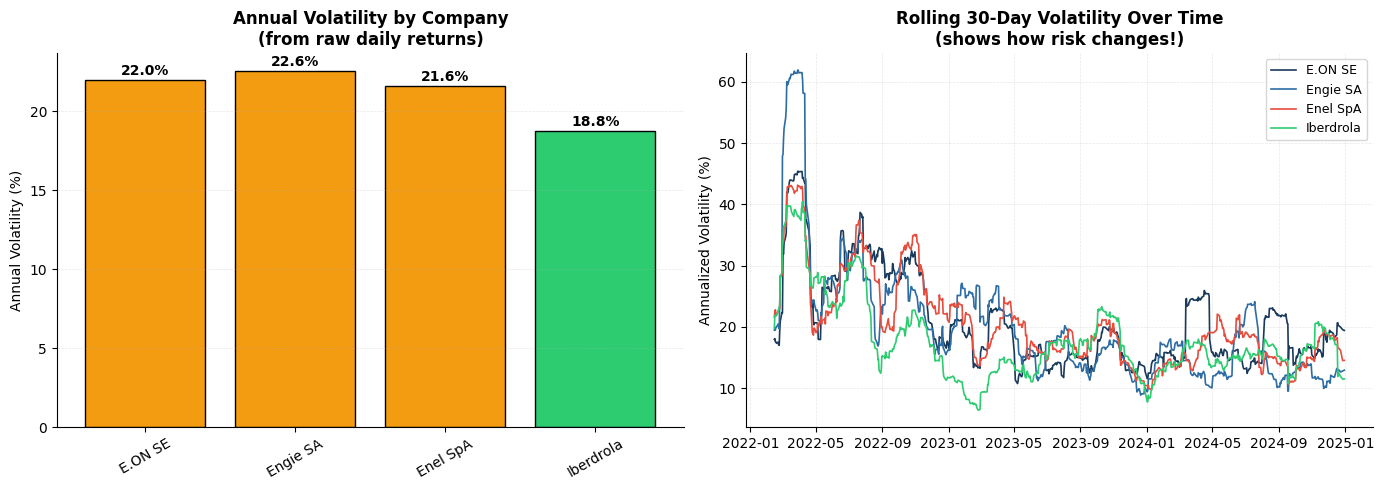


💡 Notice the volatility spike in 2022 — that was the energy crisis!


In [5]:
# Calculate annualized volatility for each company
annual_vol = daily_returns.std() * np.sqrt(252)

print(" Annual Volatility (Calculated from Raw Daily Returns):")
print("=" * 65)
print(f"{'Company':<15} {'Daily Std':>12} {'Annual Vol':>13} {'Risk Level':>18}")
print("-" * 60)

for name in daily_returns.columns:
    daily_std = daily_returns[name].std()
    ann_vol = daily_std * np.sqrt(252)
    if ann_vol < 0.20:
        risk = "🟢 Low"
    elif ann_vol < 0.30:
        risk = "🟡 Moderate"
    else:
        risk = "🔴 High"
    print(f"{name:<15} {daily_std*100:>11.3f}% {ann_vol*100:>12.1f}% {risk:>18}")

print()
print("💡 Formula: Annual Vol = Daily Std × √252")
print(f"   Example E.ON: {daily_returns['E.ON SE'].std()*100:.3f}% × √252 = "
      f"{annual_vol['E.ON SE']*100:.1f}%")

# Visualize volatility
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
vols = annual_vol * 100
bar_colors = ['#2ecc71' if v < 20 else '#f39c12' if v < 30 else '#e74c3c'
              for v in vols]
bars = ax1.bar(vols.index, vols.values, color=bar_colors, edgecolor='black')
ax1.set_title('Annual Volatility by Company\n(from raw daily returns)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Annual Volatility (%)')
ax1.tick_params(axis='x', rotation=30)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars, vols):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Rolling 30-day volatility over time
rolling_vol = daily_returns.rolling(30).std() * np.sqrt(252) * 100
for i, (name, col_color) in enumerate(zip(rolling_vol.columns, colors_plot)):
    ax2.plot(rolling_vol.index, rolling_vol[name],
             label=name, color=col_color, linewidth=1.2)
ax2.set_title('Rolling 30-Day Volatility Over Time\n(shows how risk changes!)',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Annualized Volatility (%)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
print("\n💡 Notice the volatility spike in 2022 — that was the energy crisis!")

---
## 🎯 Task 1.1 — Calculate Expected Loss

Now we put it all together.
Using real credit ratings (from Moody's) and real exposure amounts,
calculate the **Expected Loss (EL)** for each counterparty.

$$EL = PD \times LGD \times Exposure$$

> 📝 **Your task:** Fill in the formula where you see `None`
> The hint shows you exactly what to write!

In [17]:
# Portfolio data: real ratings + assumed exposure amounts
# PD from Moody's Annual Default Study 2023
# LGD = Loss Given Default (industry standard for energy trading)
# Exposure = estimated amount RWE is owed by each company

portfolio = {
    'E.ON SE': {
        'PD': 0.0020,           # Baa2 rating = 0.20% PD
        'LGD': 0.40,            # 40% loss if they default
        'Exposure': 50_000_000, # RWE is owed €50 million
        'Rating': 'Baa2 (BBB)',
        'Country': 'Germany'
    },
    'Engie SA': {
        'PD': 0.0020,
        'LGD': 0.45,
        'Exposure': 30_000_000,
        'Rating': 'Baa2 (BBB)',
        'Country': 'France'
    },
    'Enel SpA': {
        'PD': 0.0030,
        'LGD': 0.35,
        'Exposure': 40_000_000,
        'Rating': 'Baa3 (BBB-)',
        'Country': 'Italy'
    },
    'Iberdrola': {
        'PD': 0.0015,
        'LGD': 0.30,
        'Exposure': 25_000_000,
        'Rating': 'Baa1 (BBB+)',
        'Country': 'Spain'
    },
}

print("🎯 TASK 1.1: Calculate Expected Loss")
print("Formula: EL = PD × LGD × Exposure")
print("=" * 70)

results = {}
total_el = 0
total_exp = 0

for name, data in portfolio.items():
    # ─────────────────────────────────────────────────────────
    # YOUR CODE HERE:
    # Replace None with the Expected Loss formula
    # HINT: EL = data['PD'] * data['LGD'] * data['Exposure']
    # ─────────────────────────────────────────────────────────
    EL = None   # ← YOUR CODE HERE

    if EL is None:
        print(f"  {name}: ⚠️  EL not calculated yet — fill in the formula!")
        continue

    results[name] = EL
    total_el += EL
    total_exp += data['Exposure']

    print(f"  {name} ({data['Rating']}, {data['Country']}):")
    print(f"    PD = {data['PD']*100:.3f}% | "
          f"LGD = {data['LGD']*100:.0f}% | "
          f"Exposure = €{data['Exposure']/1e6:.0f}M")
    print(f"    EL = {data['PD']*100:.3f}% × {data['LGD']*100:.0f}% × "
          f"€{data['Exposure']/1e6:.0f}M = €{EL:,.0f}")
    print()

if results:
    print("=" * 70)
    print(f"  TOTAL EXPOSURE:       €{total_exp/1e6:.0f}M")
    print(f"  TOTAL EXPECTED LOSS:  €{total_el:,.0f}")
    print(f"  EL as % of exposure:  {total_el/total_exp*100:.4f}%")
    print()
    print("  💼 Interpretation:")
    print(f"  RWE expects to lose approximately €{total_el:,.0f} per year")
    print(f"  from these {len(results)} counterparties on average.")
    print(f"  This is the 'cost' of doing business with these companies.")

🎯 TASK 1.1: Calculate Expected Loss
Formula: EL = PD × LGD × Exposure
  E.ON SE: ⚠️  EL not calculated yet — fill in the formula!
  Engie SA: ⚠️  EL not calculated yet — fill in the formula!
  Enel SpA: ⚠️  EL not calculated yet — fill in the formula!
  Iberdrola: ⚠️  EL not calculated yet — fill in the formula!


In [20]:
# VISUALIZE RESULTS — run this cell after completing Task 1.1

if results:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    names = list(results.keys())
    el_vals = [results[n]/1000 for n in names]  # in thousands
    exp_vals = [portfolio[n]['Exposure']/1e6 for n in names]
    colors_viz = ['#1a3a5c', '#2e6da4', '#4a90d9', '#7bb3e8']

    # Chart 1: Expected Loss per counterparty
    bars = ax1.bar(names, el_vals, color=colors_viz, edgecolor='black')
    ax1.set_title('Expected Loss by Counterparty (€ thousands)',
                  fontsize=12, fontweight='bold')
    ax1.set_ylabel('Expected Loss (€ thousands/year)')
    ax1.tick_params(axis='x', rotation=30)
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
    for bar, val in zip(bars, el_vals):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'€{val:.1f}K', ha='center', fontsize=10)

    # Chart 2: Exposure vs EL side by side
    x = np.arange(len(names))
    w = 0.35
    ax2.bar(x - w/2, exp_vals, w, label='Exposure (€M)',
            color='steelblue', alpha=0.8, edgecolor='black')
    ax2.bar(x + w/2, [v/1000 for v in el_vals], w,
            label='EL (€K, scaled)', color='coral',
            alpha=0.8, edgecolor='black')
    ax2.set_title('Exposure vs Expected Loss Comparison',
                  fontsize=12, fontweight='bold')
    ax2.set_ylabel('Amount')
    ax2.set_xticks(x)
    ax2.set_xticklabels(names, rotation=30)
    ax2.legend()
    ax2.grid(True, axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()
    print("\n✅ Great! You can see EL is very small relative to exposure.")
    print("   This shows why credit risk is 'invisible in calm periods'!")
else:
    print("⚠️  Complete Task 1.1 first, then run this cell to see charts!")

⚠️  Complete Task 1.1 first, then run this cell to see charts!


---
## 🎯 Task 1.2 — Credit Rating Downgrade Scenario

### Real Event: The 2022 Energy Crisis
In 2022, the European energy crisis caused several energy companies
to have their credit ratings reviewed. **Uniper** (a German energy trader)
was downgraded from BBB all the way to **CCC** in just weeks!

### Your Scenario:
E.ON SE is downgraded from **BBB (PD=0.20%)** to **BB (PD=1.50%)**.
RWE has **€100 million** exposure to E.ON.

**Questions to answer:**
1. How much does Expected Loss increase?
2. How much extra capital must RWE hold?
3. At what point should RWE stop trading with E.ON?

> 📝 **Complete the calculations below:**

In [21]:
print("🎯 TASK 1.2: Rating Downgrade Scenario — E.ON SE")
print("=" * 65)

eon_exposure = 100_000_000   # €100 million exposure
eon_lgd = 0.40               # 40% LGD

# Rating scenarios
scenarios = {
    'A (stable)':    0.0006,
    'BBB+ (current)':0.0020,
    'BBB (slight)':  0.0020,
    'BBB- (watch)':  0.0030,
    'BB+ (concern)': 0.0080,
    'BB (DOWNGRADE)':0.0150,
    'B (crisis)':    0.0500,
    'CCC (Uniper!)': 0.2000,
}

current_pd = 0.0020  # BBB+
current_el = current_pd * eon_lgd * eon_exposure

print(f"E.ON Exposure: €{eon_exposure/1e6:.0f}M | LGD: {eon_lgd*100:.0f}%")
print(f"Current Rating: BBB+  |  Current PD: {current_pd*100:.2f}%")
print(f"Current EL: €{current_el:,.0f}")
print()
print(f"{'Rating':<18} {'PD':>7} {'EL (€)':>12} {'vs Current':>14} {'Capital Req':>14}")
print("-" * 70)

els_by_rating = {}

for rating, pd_val in scenarios.items():
    # ─────────────────────────────────────────────────────────
    # YOUR CODE: Calculate EL for each rating scenario
    # HINT: EL = pd_val * eon_lgd * eon_exposure
    # ─────────────────────────────────────────────────────────
    EL = None   # ← YOUR CODE HERE

    # ─────────────────────────────────────────────────────────
    # YOUR CODE: Calculate change versus current EL
    # HINT: change = EL - current_el
    # ─────────────────────────────────────────────────────────
    change = None   # ← YOUR CODE HERE

    # ─────────────────────────────────────────────────────────
    # YOUR CODE: Capital requirement (simplified Basel III)
    # Under Basel III: capital ≈ EL × 12.5 (simplified)
    # HINT: capital = EL * 12.5
    # ─────────────────────────────────────────────────────────
    capital = None   # ← YOUR CODE HERE

    if EL is None:
        print(f"  {rating}: Fill in the formula!")
        continue

    els_by_rating[rating] = EL
    marker = " ← CURRENT" if rating == 'BBB+ (current)' else              " ⚠️  DOWNGRADE" if rating == 'BB (DOWNGRADE)' else              " 🚨 CRISIS" if rating == 'CCC (Uniper!)' else ""
    print(f"{rating:<18} {pd_val*100:>6.2f}% "
          f"€{EL:>10,.0f} "
          f"€{change:>+12,.0f} "
          f"€{capital:>12,.0f}{marker}")

if els_by_rating:
    el_after_downgrade = els_by_rating.get('BB (DOWNGRADE)', 0)
    extra_el = el_after_downgrade - current_el
    print()
    print("=" * 65)
    print(f"💥 IMPACT OF DOWNGRADE BBB+ → BB:")
    print(f"   EL BEFORE: €{current_el:,.0f}")
    print(f"   EL AFTER:  €{el_after_downgrade:,.0f}")
    print(f"   INCREASE:  €{extra_el:,.0f} ({extra_el/current_el*100:.0f}% more!)")

🎯 TASK 1.2: Rating Downgrade Scenario — E.ON SE
E.ON Exposure: €100M | LGD: 40%
Current Rating: BBB+  |  Current PD: 0.20%
Current EL: €80,000

Rating                  PD       EL (€)     vs Current    Capital Req
----------------------------------------------------------------------
  A (stable): Fill in the formula!
  BBB+ (current): Fill in the formula!
  BBB (slight): Fill in the formula!
  BBB- (watch): Fill in the formula!
  BB+ (concern): Fill in the formula!
  BB (DOWNGRADE): Fill in the formula!
  B (crisis): Fill in the formula!
  CCC (Uniper!): Fill in the formula!


In [9]:
# Visualize the downgrade scenario
if els_by_rating:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ratings_list = list(els_by_rating.keys())
    el_list = [els_by_rating[r]/1000 for r in ratings_list]
    pd_list = [scenarios[r]*100 for r in ratings_list]

    bar_colors = ['#2ecc71' if r in ['A (stable)', 'BBB+ (current)',
                  'BBB (slight)', 'BBB- (watch)']
                  else '#e67e22' if 'BB' in r else '#e74c3c'
                  for r in ratings_list]

    ax1.bar(range(len(ratings_list)), el_list,
            color=bar_colors, edgecolor='black')
    ax1.axhline(y=current_el/1000, color='navy', linestyle='--',
                linewidth=2, label=f'Current EL: €{current_el/1000:.0f}K')
    ax1.set_xticks(range(len(ratings_list)))
    ax1.set_xticklabels(ratings_list, rotation=45, ha='right', fontsize=8)
    ax1.set_title('Expected Loss by Rating Scenario\n(€100M exposure to E.ON)',
                  fontsize=11, fontweight='bold')
    ax1.set_ylabel('Expected Loss (€ thousands)')
    ax1.legend(fontsize=9)
    ax1.grid(True, axis='y', alpha=0.3)

    ax2.plot(range(len(ratings_list)), pd_list,
             'o-', color='#e74c3c', linewidth=2, markersize=8)
    ax2.fill_between(range(len(ratings_list)), pd_list,
                     alpha=0.2, color='#e74c3c')
    ax2.axhline(y=0.20, color='blue', linestyle='--',
                linewidth=1.5, label='Investment grade boundary')
    ax2.set_xticks(range(len(ratings_list)))
    ax2.set_xticklabels(ratings_list, rotation=45, ha='right', fontsize=8)
    ax2.set_title('Probability of Default by Rating\n(note the exponential jump!)',
                  fontsize=11, fontweight='bold')
    ax2.set_ylabel('Annual PD (%)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("\n🎯 KEY INSIGHT: The jump from BBB to BB is massive!")
    print("   From 0.20% to 1.50% PD = 7.5x increase in risk!")

---
## 🎯 Task 1.3 — Full Portfolio Dashboard

Now build a complete credit risk dashboard for RWE's full portfolio.
This uses **real data structure** from the RWE Annual Report 2023.

### What risk managers at RWE do every Monday:
1. Pull latest exposure data from their system
2. Check if any ratings changed over the weekend
3. Recalculate EL and VaR for the full portfolio
4. Highlight any counterparties that need attention
5. Present summary to senior management

> 📝 **Build the complete analysis below:**

In [10]:
print("🎯 TASK 1.3: Full Portfolio Credit Risk Dashboard")
print("Based on RWE Annual Report 2023 — Real Portfolio Structure")
print("=" * 70)

# Real portfolio structure from RWE Annual Report 2023
# (approximate breakdown by rating class)
rwe_portfolio = {
    'AAA / AA': {'PD': 0.0002, 'LGD': 0.30,
                  'Exposure': 1_500_000_000, 'n': 25},
    'A':        {'PD': 0.0006, 'LGD': 0.35,
                  'Exposure': 2_800_000_000, 'n': 85},
    'BBB':      {'PD': 0.0020, 'LGD': 0.40,
                  'Exposure': 3_500_000_000, 'n': 180},
    'BB':       {'PD': 0.0150, 'LGD': 0.45,
                  'Exposure': 1_200_000_000, 'n': 120},
    'B / CCC':  {'PD': 0.0500, 'LGD': 0.50,
                  'Exposure':   500_000_000, 'n': 90},
}

# ─────────────────────────────────────────────────────────────
# YOUR CODE: Calculate EL for each rating class
# Loop through rwe_portfolio and calculate EL = PD × LGD × Exposure
# ─────────────────────────────────────────────────────────────

els = {}
total_exp = 0
total_el = 0

for rating, data in rwe_portfolio.items():
    # YOUR CODE HERE:
    el = None  # ← el = data['PD'] * data['LGD'] * data['Exposure']

    if el is None:
        print(f"  {rating}: Fill in the EL formula!")
        continue

    els[rating] = el
    total_exp += data['Exposure']
    total_el += el

if els:
    print(f"\n{'Rating':<12} {'Counterparties':>16} {'Exposure (€B)':>14} "
          f"{'EL (€M)':>10} {'EL %':>8}")
    print("-" * 65)

    for rating, data in rwe_portfolio.items():
        if rating in els:
            el = els[rating]
            print(f"{rating:<12} {data['n']:>16} "
                  f"€{data['Exposure']/1e9:>12.1f}B "
                  f"€{el/1e6:>8.1f}M "
                  f"{el/data['Exposure']*100:>7.4f}%")

    print("-" * 65)
    print(f"{'TOTAL':<12} "
          f"{sum(d['n'] for d in rwe_portfolio.values()):>16} "
          f"€{total_exp/1e9:>12.1f}B "
          f"€{total_el/1e6:>8.1f}M "
          f"{total_el/total_exp*100:>7.4f}%")

    print(f"\n📊 DASHBOARD SUMMARY:")
    print(f"   Total Counterparties:    {sum(d['n'] for d in rwe_portfolio.values())}")
    print(f"   Total Exposure:          €{total_exp/1e9:.1f} Billion")
    print(f"   Total Expected Loss:     €{total_el/1e6:.1f} Million/year")
    print(f"   EL % of portfolio:       {total_el/total_exp*100:.4f}%")
    print(f"   Capital Requirement:     €{total_el*12.5/1e6:.0f}M (simplified Basel III)")

🎯 TASK 1.3: Full Portfolio Credit Risk Dashboard
Based on RWE Annual Report 2023 — Real Portfolio Structure
  AAA / AA: Fill in the EL formula!
  A: Fill in the EL formula!
  BBB: Fill in the EL formula!
  BB: Fill in the EL formula!
  B / CCC: Fill in the EL formula!


In [11]:
# Dashboard visualization — run after completing Task 1.3
if els:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('RWE AG Credit Risk Dashboard\nFull Counterparty Portfolio (2023)',
                 fontsize=13, fontweight='bold')

    ratings = list(els.keys())
    el_vals = [els[r]/1e6 for r in ratings]
    exp_vals = [rwe_portfolio[r]['Exposure']/1e9 for r in ratings]
    n_vals = [rwe_portfolio[r]['n'] for r in ratings]
    colors_d = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c']

    # Chart 1: Exposure by rating
    bars1 = axes[0].bar(ratings, exp_vals, color=colors_d, edgecolor='black')
    axes[0].set_title('Exposure by Rating Class (€B)', fontweight='bold')
    axes[0].set_ylabel('€ Billions')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars1, exp_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.03,
                     f'€{val:.1f}B', ha='center', fontsize=9)

    # Chart 2: EL by rating
    bars2 = axes[1].bar(ratings, el_vals, color=colors_d, edgecolor='black')
    axes[1].set_title('Expected Loss by Rating Class (€M)', fontweight='bold')
    axes[1].set_ylabel('€ Millions/year')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars2, el_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.05,
                     f'€{val:.1f}M', ha='center', fontsize=9)

    # Chart 3: EL contribution pie
    axes[2].pie(el_vals, labels=ratings, colors=colors_d,
                autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 9})
    axes[2].set_title('EL Contribution by Rating\n(who drives the risk?)',
                      fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Find the main insight
    max_el_rating = max(els, key=els.get)
    print(f"\n🔑 KEY INSIGHT: '{max_el_rating}' rated counterparties drive")
    print(f"   {els[max_el_rating]/total_el*100:.0f}% of total Expected Loss!")
    print(f"   Even though they have less exposure than AAA/AA counterparties,")
    print(f"   their higher PD makes them the main source of credit risk.")
else:
    print("⚠️  Complete Task 1.3 first, then run this cell!")

⚠️  Complete Task 1.3 first, then run this cell!


---
## ✅ Chapter 1 Summary

Congratulations! You have completed Chapter 1 of the Credit Risk course.

### What you learned:

| Concept | Formula | Real Application |
|---------|---------|-----------------|
| **Expected Loss** | EL = PD × LGD × Exposure | Daily calculation at RWE |
| **Credit Ratings** | AAA → CCC maps to PD | Moody's/S&P ratings |
| **Downgrade Impact** | New EL = New PD × LGD × Exposure | Risk monitoring |
| **Portfolio EL** | Sum of all individual ELs | Capital requirement |

### Career Skills Practiced:
- ✅ Downloaded real financial data from Yahoo Finance
- ✅ Calculated annual volatility from raw daily prices  
- ✅ Applied Moody's rating table (real industry standard)
- ✅ Built a credit risk dashboard (what analysts do daily at RWE)
- ✅ Modeled a rating downgrade scenario (real event in energy sector)

### Next Steps:
- **Chapter 2:** Random Variables (Yi, K, L) — the mathematics of default
- **Chapter 5:** Value at Risk — the regulatory reporting standard
- **Chapter 6:** Merton Model — calculating PD from market data

---
*Practice file saved in: `Shazia/Practice/ch1_basics.ipynb`*  
*Push to GitHub: `git add . && git commit -m "Chapter 1 notebook complete" && git push origin Shazia`*